In [7]:
import kagglehub

# Download latest version
path1 = kagglehub.dataset_download("crawford/cat-dataset")

print("Path1 to dataset files:", path1)
import kagglehub

# Download latest version
path2 = kagglehub.dataset_download("yashdogra/dogs-dataset")

print("Path2 to dataset files:", path2)

C:\Users\shrey\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|█████████████████████████████████████████████████████████████████████████████| 4.04G/4.04G [03:44<00:00, 19.3MB/s]

Extracting files...


Path1 to dataset files: C:\Users\shrey\.cache\kagglehub\datasets\crawford\cat-dataset\versions\2


100%|█████████████████████████████████████████████████████████████████████████████| 2.73G/2.73G [02:39<00:00, 18.4MB/s]

Extracting files...


Path2 to dataset files: C:\Users\shrey\.cache\kagglehub\datasets\yashdogra\dogs-dataset\versions\6


In [15]:
import cv2
import time
from ultralytics import YOLO
import os
from pathlib import Path
# Data path (update to your dataset folder or YAML file)
DATA_PATH = "C:\\Users\\shrey\\.cache\\kagglehub\\datasets\\crawford\\cat-dataset\\versions\\2;C:\\Users\\shrey\\.cache\\kagglehub\\datasets\\yashdogra\\dogs-dataset\\versions\\6"  
print("loaded")
# Load or train model

loaded


In [16]:
import os
import shutil

# ORIGINAL DATASET PATHS (your kagglehub paths)
cat_source = r"C:\Users\shrey\.cache\kagglehub\datasets\crawford\cat-dataset\versions\2"
dog_source = r"C:\Users\shrey\.cache\kagglehub\datasets\yashdogra\dogs-dataset\versions\6"

# NEW COMBINED DATASET
base_dir = r"C:\Users\shrey\pet_dataset"
cat_dest = os.path.join(base_dir, "cats")
dog_dest = os.path.join(base_dir, "dogs")

os.makedirs(cat_dest, exist_ok=True)
os.makedirs(dog_dest, exist_ok=True)

def copy_images(src, dest):
    for root, dirs, files in os.walk(src):
        for file in files:
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                src_file = os.path.join(root, file)
                dst_file = os.path.join(dest, file)
                if not os.path.exists(dst_file):
                    shutil.copy(src_file, dst_file)

print("Copying cat images...")
copy_images(cat_source, cat_dest)

print("Copying dog images...")
copy_images(dog_source, dog_dest)

print("✅ Dataset successfully combined!")


Copying cat images...
Copying dog images...
✅ Dataset successfully combined!


In [17]:
DATASET_PATH = r"C:\Users\shrey\pet_dataset"


In [18]:
import os

DATASET_PATH = r"C:\Users\shrey\pet_dataset"

print("Dataset exists:", os.path.exists(DATASET_PATH))
print("Folders inside:", os.listdir(DATASET_PATH))

Dataset exists: True
Folders inside: ['cats', 'dogs']


In [19]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH = r"C:\Users\shrey\pet_dataset"

IMG_SIZE = 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

Found 24459 images belonging to 2 classes.
Found 6114 images belonging to 2 classes.


In [20]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model created successfully!")

✅ Model created successfully!


C:\Users\shrey\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.fit(train_generator, validation_data=val_generator, epochs=5)

Epoch 1/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 1042s 1s/step - accuracy: 0.7162 - loss: 0.5607 - val_accuracy: 0.7785 - val_loss: 0.4765
Epoch 2/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 1041s 1s/step - accuracy: 0.7841 - loss: 0.4598 - val_accuracy: 0.8299 - val_loss: 0.3882
Epoch 3/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 1030s 1s/step - accuracy: 0.8421 - loss: 0.3634 - val_accuracy: 0.8773 - val_loss: 0.2956
Epoch 4/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 835s 1s/step - accuracy: 0.8810 - loss: 0.2833 - val_accuracy: 0.8860 - val_loss: 0.2938
Epoch 5/5
765/765 ━━━━━━━━━━━━━━━━━━━━ 577s 755ms/step - accuracy: 0.9130 - loss: 0.2125 - val_accuracy: 0.9181 - val_loss: 0.2153



🐱 DOG vs CAT CLASSIFIER - COMPARE WITH DATASET
Model trained on thousands of cat/dog images



📁 Enter image path (or 'quit'):  images.jpeg



✅ RESULT: DOG 🐶
📊 Confidence: 100.0%
🔍 Compared with 24459 dataset images


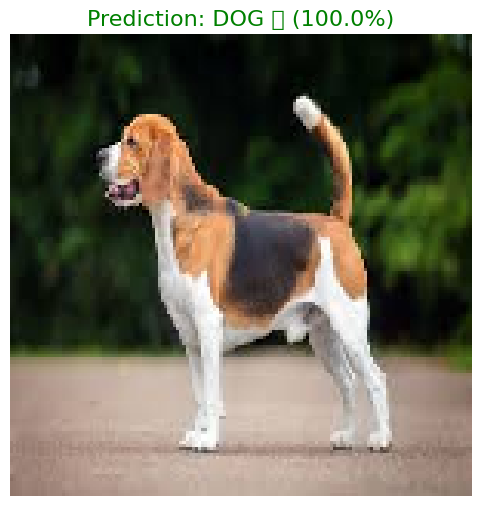


📁 Enter image path (or 'quit'):  Cat1.jpeg



✅ RESULT: CAT 🐱
📊 Confidence: 53.7%
🔍 Compared with 24459 dataset images


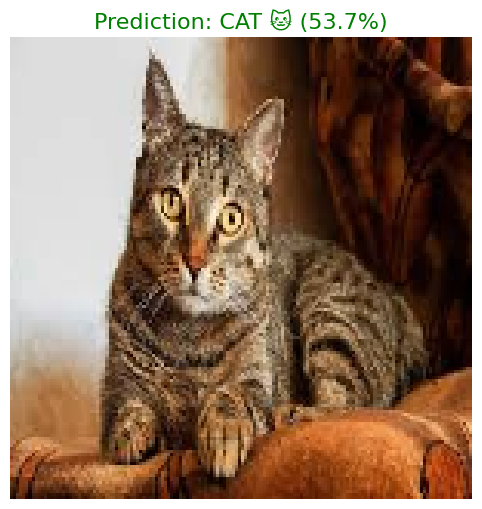

In [ ]:
# ================================
# 🐱 DOG vs CAT CLASSIFIER
# ================================

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Assume model and train_generator are already defined and trained
# Example: model = ... (loaded/trained earlier)
# IMG_SIZE should match the size used during training
IMG_SIZE = 150   # adjust if your training used a different size

print("\n" + "="*60)
print("🐱 DOG vs CAT CLASSIFIER - COMPARE WITH DATASET")
print("Model trained on thousands of cat/dog images")
print("="*60)

while True:
    image_path = input("\n📁 Enter image path (or 'quit'): ").strip()
    
    if image_path.lower() == 'quit':
        print("👋 Thanks for using Cat-Dog Classifier!")
        break
        
    if not os.path.exists(image_path):
        print("❌ File not found!")
        continue
    
    # Load and preprocess uploaded image
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Model COMPARES against entire dataset (learned during training)
    prediction = model.predict(img_array, verbose=0)[0][0]
    
    # Result based on comparison with all training data
    if prediction > 0.5:
        label = "DOG 🐶"
        confidence = f"{prediction*100:.1f}%"
    else:
        label = "CAT 🐱" 
        confidence = f"{(1-prediction)*100:.1f}%"
    
    print(f"\n✅ RESULT: {label}")
    print(f"📊 Confidence: {confidence}")
    print(f"🔍 Compared with {len(train_generator.classes)} dataset images")
    
    # # Show image with prediction
    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.title(f"Prediction: {label} ({confidence})", fontsize=16, color='green')
    plt.axis('off')
    plt.show()
